**Case Study:**

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
df = pd.read_csv("dino_clean.csv")

1)  The Changing of the Guard: How did the biodiversity of dinosaur types shift across geological eras?

C:\Users\gayat\AppData\Local\Temp\ipykernel_18504\2761521194.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_biodiversity = df.groupby(['era', 'type'])['name'].nunique().reset_index()


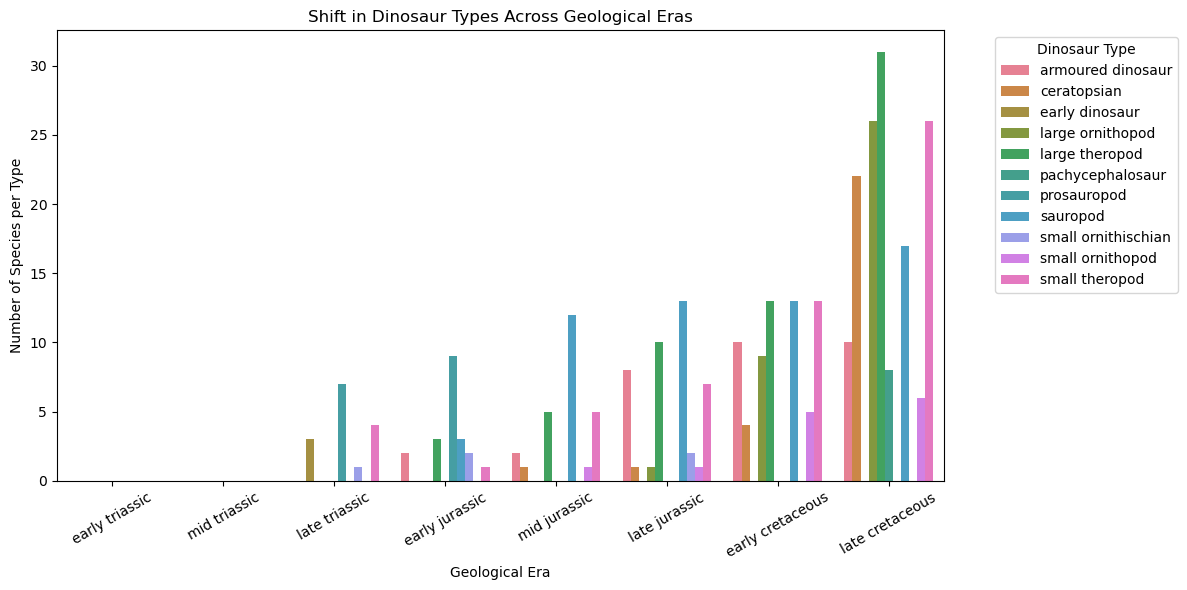

In [15]:
era_order = [
    "early triassic", "mid triassic", "late triassic",
    "early jurassic", "mid jurassic", "late jurassic",
    "early cretaceous", "late cretaceous"
]

df['era'] = df['era'].astype(str).str.strip().str.lower()
df['era'] = pd.Categorical(df['era'], categories=era_order, ordered=True)

type_biodiversity = df.groupby(['era', 'type'])['name'].nunique().reset_index()
type_biodiversity.rename(columns={'name': 'species_count'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=type_biodiversity,
    x='era',
    y='species_count',
    hue='type',
    order=era_order
)

plt.title("Shift in Dinosaur Types Across Geological Eras")
plt.xlabel("Geological Era")
plt.ylabel("Number of Species per Type")
plt.xticks(rotation=30)
plt.legend(title="Dinosaur Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

2) Live Fast, Die Young?: Did dinosaur species that appeared later in history exist for shorter periods?

C:\Users\gayat\AppData\Local\Temp\ipykernel_18504\4254681350.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


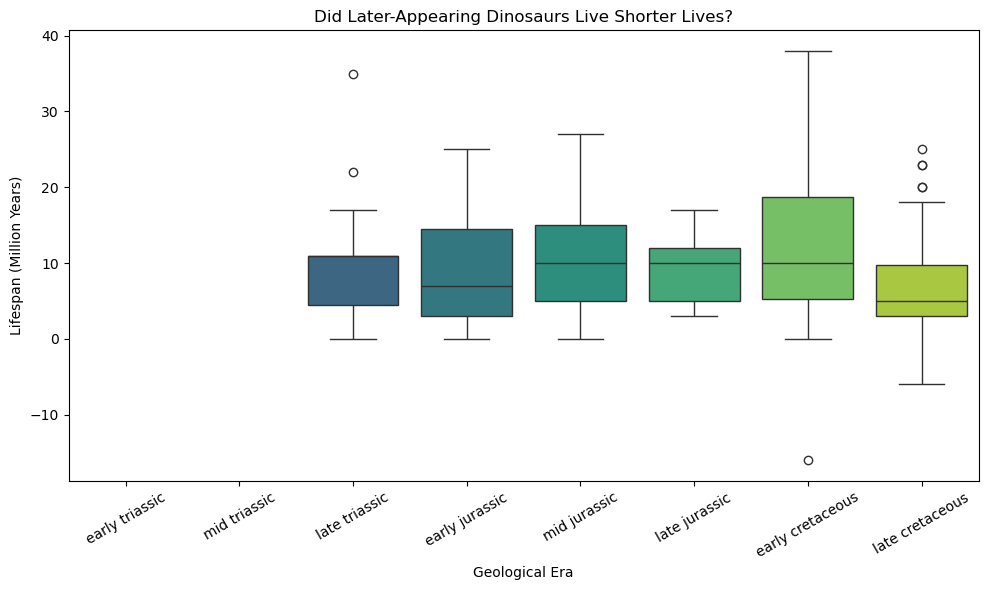

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='era',
    y='lifespan',
    order=era_order,
    palette="viridis"
)

plt.title("Did Later-Appearing Dinosaurs Live Shorter Lives?")
plt.xlabel("Geological Era")
plt.ylabel("Lifespan (Million Years)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



3) The Rise of the Apex Predators: Did theropods consistently get larger over geological time?    

C:\Users\gayat\AppData\Local\Temp\ipykernel_18504\1757604342.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(  # using violins but cut off into half like ridge
C:\Users\gayat\AppData\Local\Temp\ipykernel_18504\1757604342.py:10: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(  # using violins but cut off into half like ridge


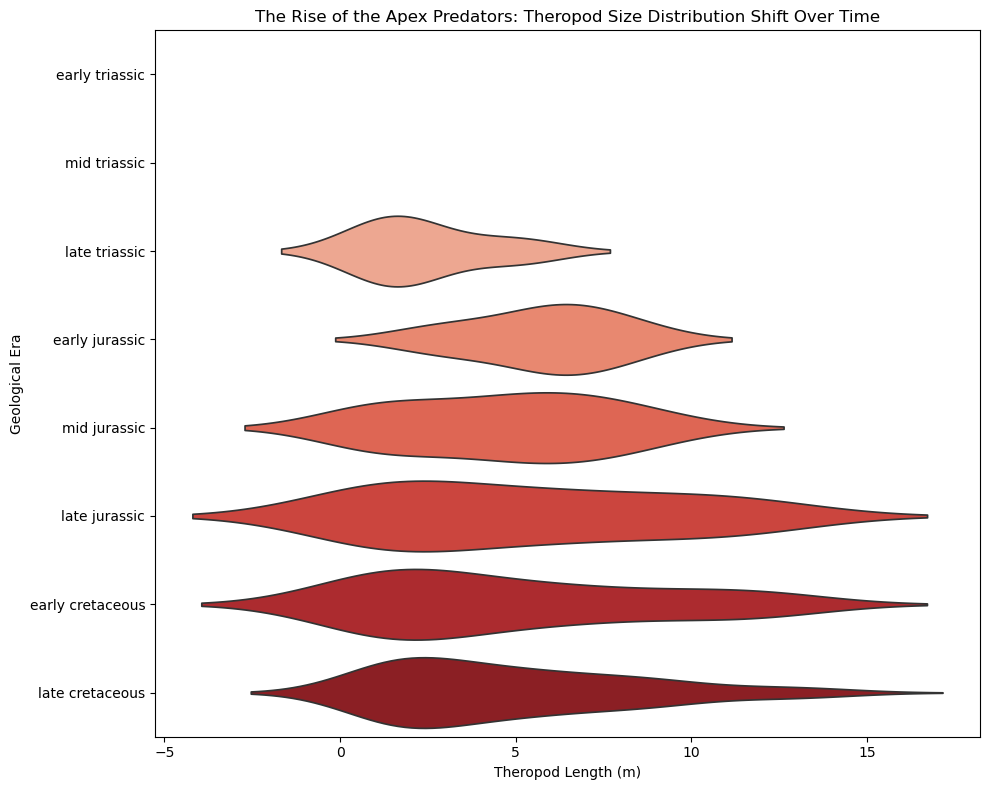

In [27]:

theropods = df[df['type'].str.contains("theropod", case=False, na=False)].copy()

theropods['length_clean'] = pd.to_numeric(theropods['length_clean'], errors='coerce')


theropods['era'] = pd.Categorical(theropods['era'], categories=era_order, ordered=True)

plt.figure(figsize=(10, 8))

sns.violinplot(  # using violins but cut off into half like ridge
    data=theropods,
    x='length_clean',
    y='era',
    order=era_order,
    scale="width",
    inner=None,
    palette="Reds"
)

plt.title("The Rise of the Apex Predators: Theropod Size Distribution Shift Over Time")
plt.xlabel("Theropod Length (m)")
plt.ylabel("Geological Era")
plt.tight_layout()
plt.show()


4) Continental Drift and Dinosaur Distribution: Are specific eras of dinosaurs geographically concentrated?

C:\Users\gayat\AppData\Local\Temp\ipykernel_18504\817024716.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  geo_dist = df.groupby(['era', 'continent'])['name'].nunique().reset_index()


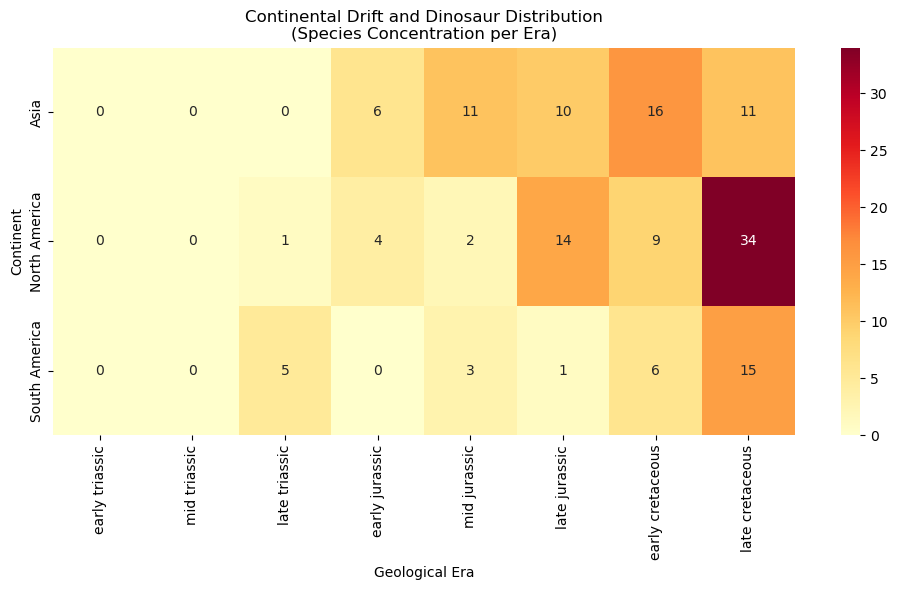

In [33]:
geo_dist = df.groupby(['era', 'continent'])['name'].nunique().reset_index()
geo_dist.rename(columns={'name': 'species_count'}, inplace=True)

geo_pivot = geo_dist.pivot(index='continent', columns='era', values='species_count').fillna(0)

geo_pivot = geo_pivot[[
    "early triassic", "mid triassic", "late triassic",
    "early jurassic", "mid jurassic", "late jurassic",
    "early cretaceous", "late cretaceous"
]]

plt.figure(figsize=(10, 6))
sns.heatmap(geo_pivot, cmap="YlOrRd", annot=True, fmt=".0f")

plt.title("Continental Drift and Dinosaur Distribution\n(Species Concentration per Era)")
plt.xlabel("Geological Era")
plt.ylabel("Continent")
plt.tight_layout()
plt.show()

5)The Paleontologist's Bias: Has the "size bias" in dinosaur discovery changed over the last century?

In [38]:
df['year_clean'] = pd.to_numeric(df['year_clean'], errors='coerce')
df['length_clean'] = pd.to_numeric(df['length_clean'], errors='coerce')

bias_df = df.dropna(subset=['year_clean', 'length_clean']).copy()
bias_df['decade'] = (bias_df['year_clean'] // 10) * 10

C:\Users\gayat\AppData\Local\Temp\ipykernel_18504\2957574547.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


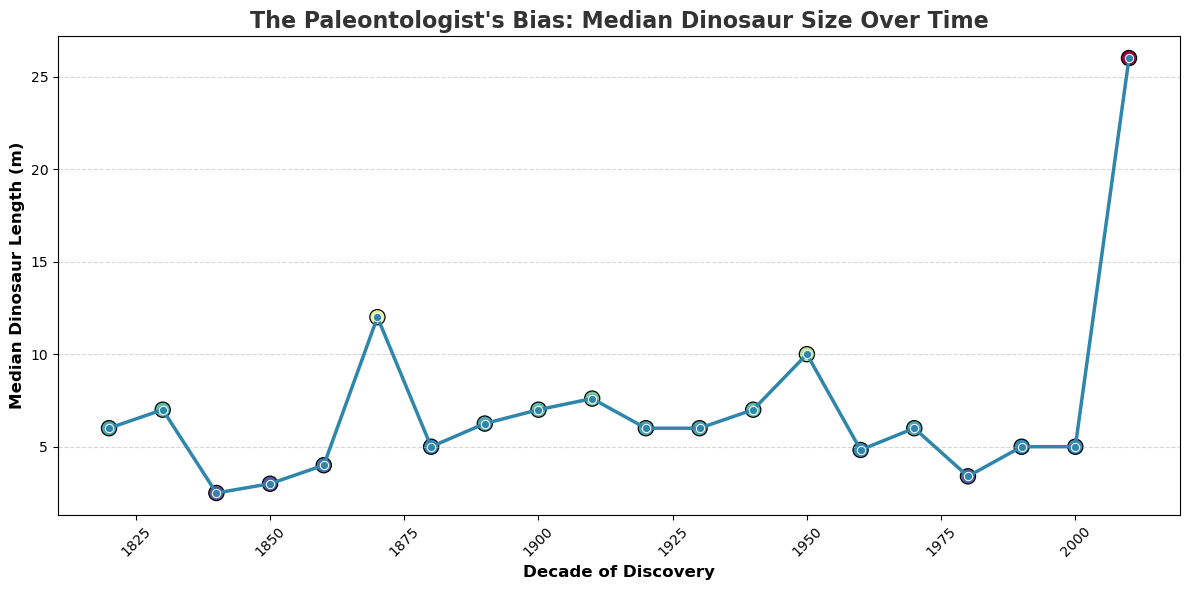

In [39]:
plt.figure(figsize=(12, 6))

# Smooth line with markers, using a nice gradient palette
sns.lineplot(
    data=bias_df,
    x='decade',
    y='length_clean',
    estimator='median',
    ci=None,
    marker='o',
    linewidth=2.5,
    color='#2E86AB'  # Base line color
)

# Add scatter points with color gradient by size
sns.scatterplot(
    data=bias_df.groupby('decade')['length_clean'].median().reset_index(),
    x='decade',
    y='length_clean',
    hue='length_clean',
    palette='Spectral_r',
    s=120,
    edgecolor='black',
    legend=False
)

plt.title(
    "The Paleontologist's Bias: Median Dinosaur Size Over Time",
    fontsize=16,
    weight='bold',
    color='#333333'
)
plt.xlabel("Decade of Discovery", fontsize=12, weight='bold')
plt.ylabel("Median Dinosaur Length (m)", fontsize=12, weight='bold')
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
